In [8]:
pip install wfdb neurokit2 pandas numpy matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
   ---------------------------------------- 0.0/688.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/688.9 kB ? eta -:--:--
   --------------- ------------------------ 262.1/688.9 kB ? eta -:--:--
   ---------------------------------------- 688.9/688.9 kB 1.3 MB/s  0:00:00
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
    --------------------------------------- 0.3/11.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.1 MB 1.5 MB/s eta 0:00:08
   -- ------------------------------------- 0.8/11.1 MB 1.4 MB/s eta 0:00:08
   --- ------------------------------------ 1.0/11.1 MB 1.5 MB/s eta 0:00:07
   ---- ----------------------------------- 1.3/11.1 MB 1.5 MB/s eta 0:00:

Imports


In [9]:
import wfdb
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("All libraries loaded successfully")

All libraries loaded successfully


Download and load one ECG record

In [10]:
# Download record 100 from MIT-BIH database (happens once, cached after)
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

# Extract the signal
signal = record.p_signal[:, 0]  # Lead I only
fs = record.fs                   # Sampling frequency (360 Hz)

print(f"Signal length: {len(signal)} samples")
print(f"Sampling rate: {fs} Hz")
print(f"Duration: {len(signal)/fs:.1f} seconds")
print(f"Number of annotations: {len(annotation.symbol)}")
print(f"Unique beat types: {set(annotation.symbol)}")

Signal length: 650000 samples
Sampling rate: 360 Hz
Duration: 1805.6 seconds
Number of annotations: 2274
Unique beat types: {'+', 'A', 'V', 'N'}


Plot the first ECG

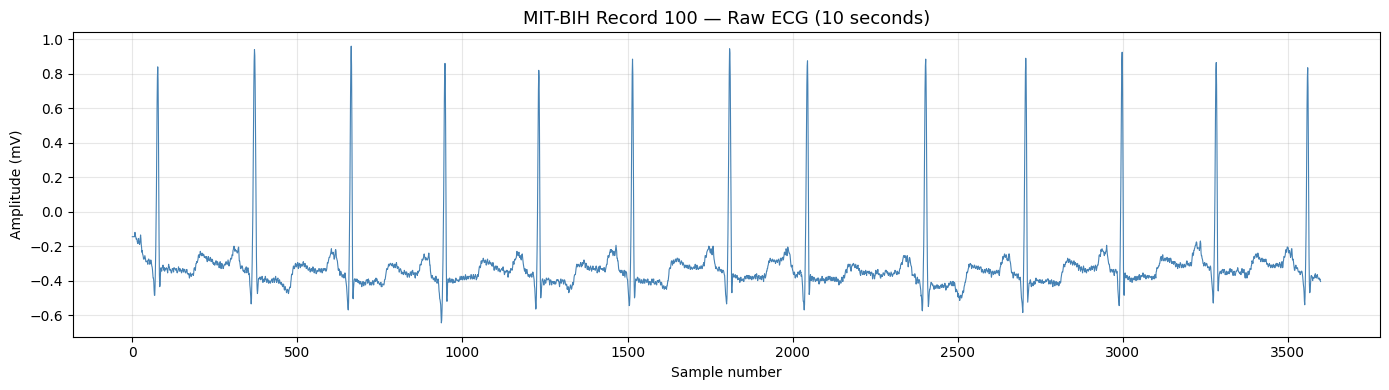

In [11]:
# Plot 10 seconds of raw ECG
samples_10s = 10 * fs  # 3600 samples

plt.figure(figsize=(14, 4))
plt.plot(signal[:samples_10s], color='steelblue', linewidth=0.8)
plt.title('MIT-BIH Record 100 — Raw ECG (10 seconds)', fontsize=13)
plt.xlabel('Sample number')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

See the beat annotations

In [12]:
# Show what the annotations mean
beat_counts = pd.Series(annotation.symbol).value_counts()
print("Beat type distribution:")
print(beat_counts)
print("\nKey types:")
print("N = Normal beat")
print("V = Premature ventricular contraction (arrhythmia)")
print("A = Atrial premature beat")
print("/ = Pacemaker beat")

Beat type distribution:
N    2239
A      33
+       1
V       1
Name: count, dtype: int64

Key types:
N = Normal beat
V = Premature ventricular contraction (arrhythmia)
A = Atrial premature beat
/ = Pacemaker beat


Clean the signal

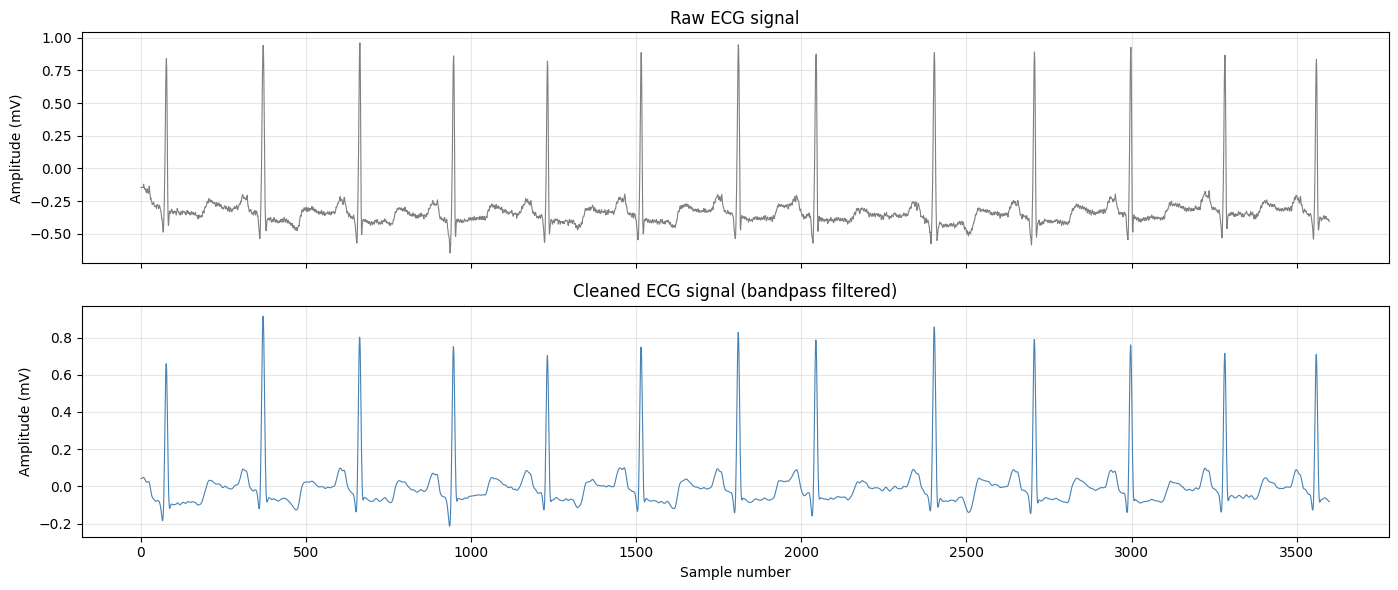

In [13]:
# Clean the ECG signal using a bandpass filter
#  removes baseline wander (low freq noise)
# and high frequency muscle artifacts
cleaned_signal = nk.ecg_clean(signal, sampling_rate=fs)

# Plot raw vs cleaned — side by side comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(signal[:samples_10s], color='gray', linewidth=0.8)
axes[0].set_title('Raw ECG signal')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(cleaned_signal[:samples_10s], color='steelblue', linewidth=0.8)
axes[1].set_title('Cleaned ECG signal (bandpass filtered)')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_xlabel('Sample number')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Detect R-peaks

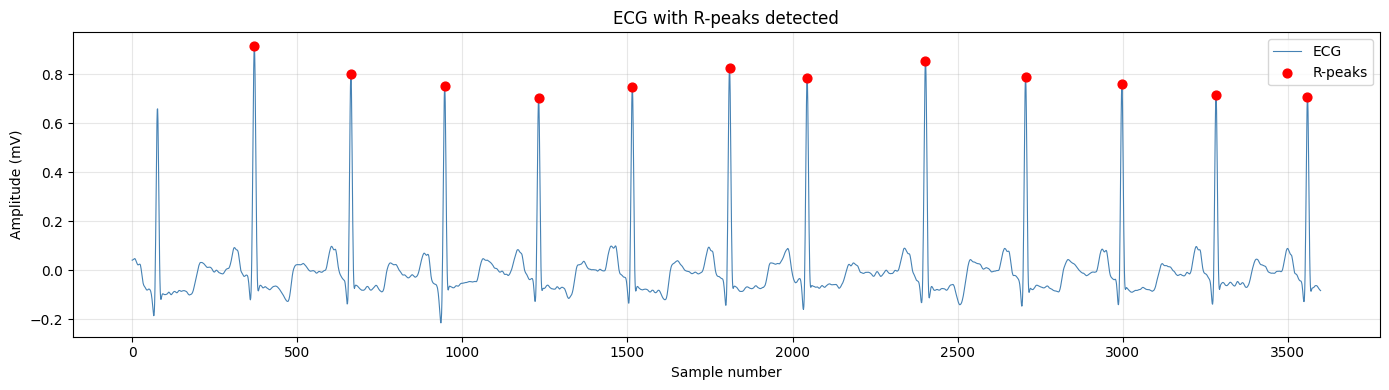

Total R-peaks detected: 2270
Expected from annotations: 2274


In [14]:
# Detect R-peaks (the top of each QRS spike)
peaks, info = nk.ecg_peaks(cleaned_signal, sampling_rate=fs)
r_peaks = info['ECG_R_Peaks']

# Plot with R-peaks marked
plt.figure(figsize=(14, 4))
plt.plot(cleaned_signal[:samples_10s], color='steelblue', linewidth=0.8, label='ECG')
plt.scatter(
    r_peaks[r_peaks < samples_10s],
    cleaned_signal[r_peaks[r_peaks < samples_10s]],
    color='red', s=40, zorder=5, label='R-peaks'
)
plt.title('ECG with R-peaks detected')
plt.xlabel('Sample number')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total R-peaks detected: {len(r_peaks)}")
print(f"Expected from annotations: {len(annotation.sample)}")

Segment individual heartbeats

In [15]:
# Extract individual beat windows around each R-peak
# 90 samples before, 110 samples after = 200 sample window per beat
before = 90
after = 110
beats = []
labels = []

# Map annotation sample positions to beat types
ann_dict = dict(zip(annotation.sample, annotation.symbol))

for peak in r_peaks:
    # Only take beats that fit within signal boundaries
    if peak - before < 0 or peak + after >= len(cleaned_signal):
        continue
    
    # Extract the beat window
    beat = cleaned_signal[peak - before : peak + after]
    
    # Find the closest annotation to this peak
    closest_ann = min(annotation.sample, key=lambda x: abs(x - peak))
    
    # Only use if annotation is within 50 samples of our detected peak
    if abs(closest_ann - peak) < 50:
        beat_label = ann_dict[closest_ann]
        # Keep only N (normal) and V (ventricular) beats for now
        if beat_label in ['N', 'V', 'A']:
            beats.append(beat)
            labels.append(beat_label)

beats = np.array(beats)
labels = np.array(labels)

print(f"Total beats extracted: {len(beats)}")
print(f"Beat shape: {beats.shape}  ← (num_beats, 200 samples)")
print(f"Label distribution: {pd.Series(labels).value_counts().to_dict()}")

Total beats extracted: 2270
Beat shape: (2270, 200)  ← (num_beats, 200 samples)
Label distribution: {'N': 2237, 'A': 33}


Visualize individual beats overlaid

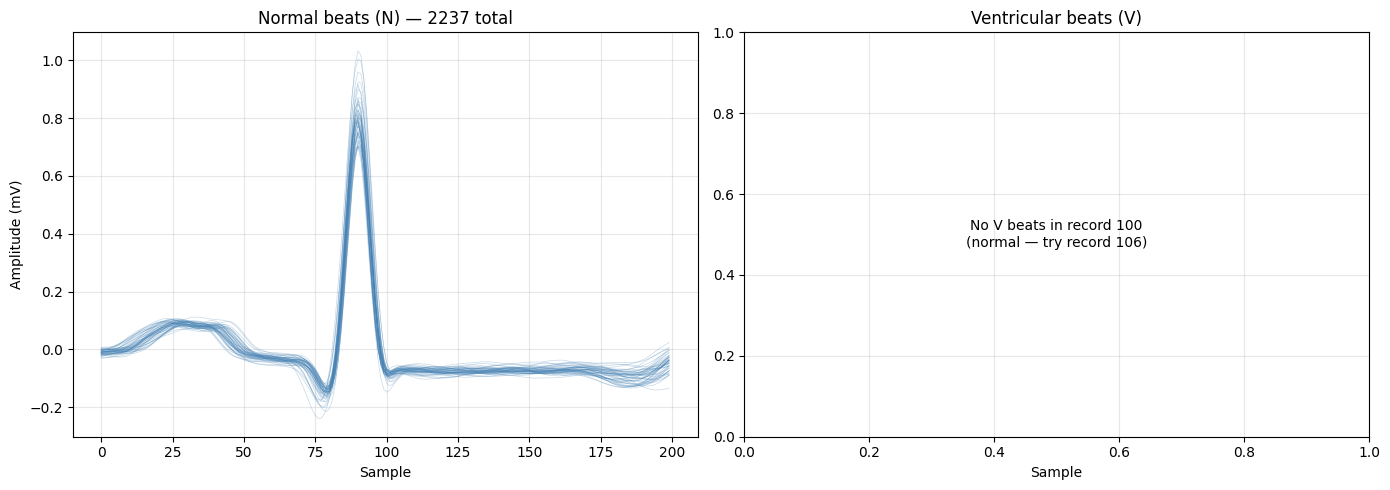

In [16]:
# Plot all Normal beats overlaid in blue, Ventricular in red
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal_beats = beats[labels == 'N']
v_beats = beats[labels == 'V']

# Normal beats
for beat in normal_beats[:50]:
    axes[0].plot(beat, color='steelblue', alpha=0.3, linewidth=0.5)
axes[0].set_title(f'Normal beats (N) — {len(normal_beats)} total')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, alpha=0.3)

# Ventricular beats — may be few in record 100
if len(v_beats) > 0:
    for beat in v_beats:
        axes[1].plot(beat, color='crimson', alpha=0.5, linewidth=0.8)
    axes[1].set_title(f'Ventricular beats (V) — {len(v_beats)} total')
else:
    axes[1].text(0.5, 0.5, 'No V beats in record 100\n(normal — try record 106)',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Ventricular beats (V)')

axes[1].set_xlabel('Sample')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Load more records to get arrhythmia beats

In [17]:
# Records known to have ventricular beats
records_to_load = ['100', '106', '119', '200', '208']

all_beats = []
all_labels = []

for rec_name in records_to_load:
    print(f"Loading record {rec_name}...")
    rec = wfdb.rdrecord(rec_name, pn_dir='mitdb')
    ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')
    
    sig = rec.p_signal[:, 0]
    sig_clean = nk.ecg_clean(sig, sampling_rate=360)
    _, inf = nk.ecg_peaks(sig_clean, sampling_rate=360)
    peaks_r = inf['ECG_R_Peaks']
    ann_map = dict(zip(ann.sample, ann.symbol))
    
    for peak in peaks_r:
        if peak - 90 < 0 or peak + 110 >= len(sig_clean):
            continue
        beat = sig_clean[peak - 90: peak + 110]
        closest = min(ann.sample, key=lambda x: abs(x - peak))
        if abs(closest - peak) < 50:
            lbl = ann_map[closest]
            if lbl in ['N', 'V']:
                all_beats.append(beat)
                all_labels.append(lbl)

all_beats = np.array(all_beats)
all_labels = np.array(all_labels)

print(f"\nTotal dataset: {len(all_beats)} beats")
print(pd.Series(all_labels).value_counts())

Loading record 100...
Loading record 106...
Loading record 119...
Loading record 200...
Loading record 208...

Total dataset: 11375 beats
N    8608
V    2767
Name: count, dtype: int64


 Visualize N vs V beats side by side

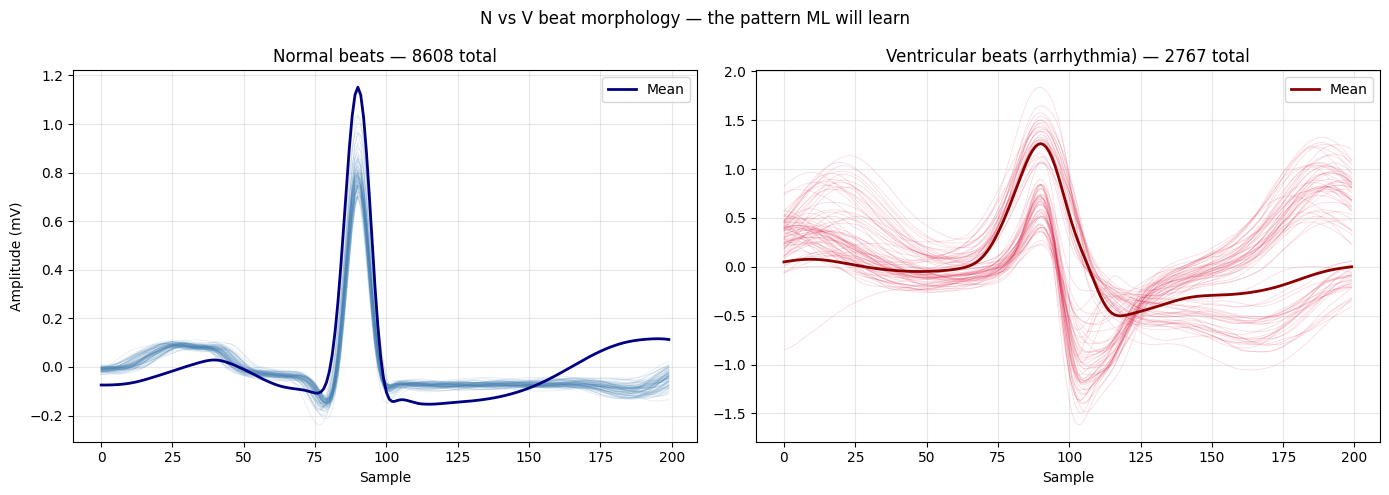

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_beats = all_beats[all_labels == 'N']
v_beats = all_beats[all_labels == 'V']

for beat in n_beats[:80]:
    axes[0].plot(beat, color='steelblue', alpha=0.15, linewidth=0.6)
axes[0].plot(n_beats.mean(axis=0), color='navy', linewidth=2, label='Mean')
axes[0].set_title(f'Normal beats — {len(n_beats)} total')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for beat in v_beats[:80]:
    axes[1].plot(beat, color='crimson', alpha=0.15, linewidth=0.6)
axes[1].plot(v_beats.mean(axis=0), color='darkred', linewidth=2, label='Mean')
axes[1].set_title(f'Ventricular beats (arrhythmia) — {len(v_beats)} total')
axes[1].set_xlabel('Sample')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('N vs V beat morphology — the pattern ML will learn', fontsize=12)
plt.tight_layout()
plt.show()

 Train the first classifier

In [20]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Prepare data
X = all_beats
y = (all_labels == 'V').astype(int)  # 0 = Normal, 1 = Ventricular

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Train Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Ventricular']))

Training samples: 9100
Test samples: 2275

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1722
 Ventricular       1.00      1.00      1.00       553

    accuracy                           1.00      2275
   macro avg       1.00      1.00      1.00      2275
weighted avg       1.00      1.00      1.00      2275



Confusion Matrix

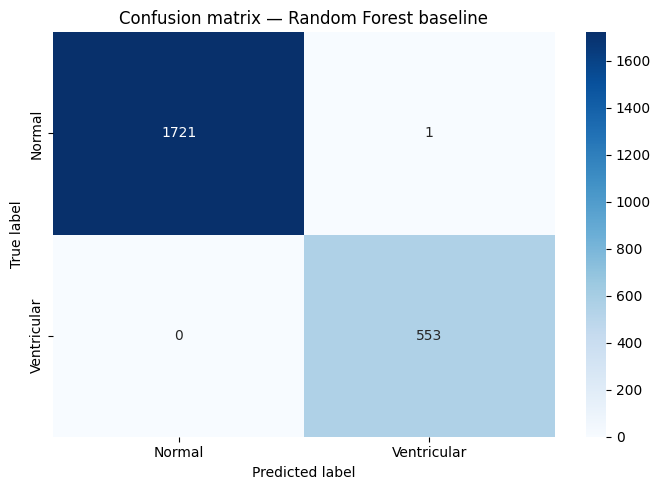

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Ventricular'],
            yticklabels=['Normal', 'Ventricular'])
plt.title('Confusion matrix — Random Forest baseline')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

Proper patient-level split (the professional version)

Loading train records...
Loading unseen test patient (208)...

Test patient (208): 2568 beats
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99      1579
 Ventricular       0.97      1.00      0.99       989

    accuracy                           0.99      2568
   macro avg       0.99      0.99      0.99      2568
weighted avg       0.99      0.99      0.99      2568



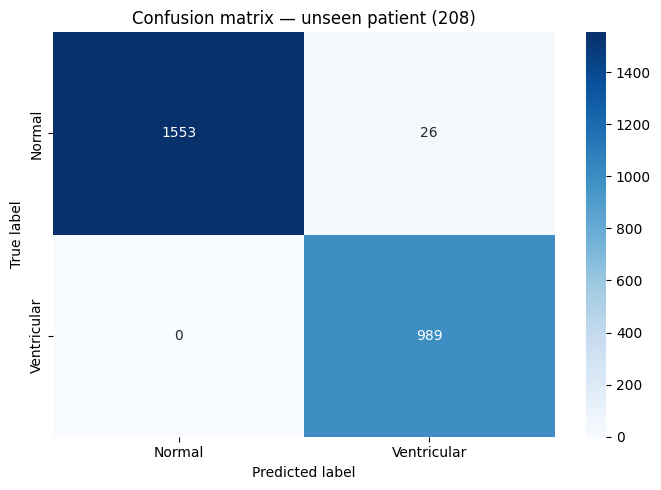

In [23]:
# Proper evaluation: train on some patients, test on completely unseen patients
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

train_records = ['100', '106', '119', '200']
test_records  = ['208']  # completely held out patient

def load_beats(rec_list, label_set=['N', 'V']):
    beats, labels = [], []
    for rec_name in rec_list:
        rec = wfdb.rdrecord(rec_name, pn_dir='mitdb')
        ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')
        sig = nk.ecg_clean(rec.p_signal[:, 0], sampling_rate=360)
        _, inf = nk.ecg_peaks(sig, sampling_rate=360)
        ann_map = dict(zip(ann.sample, ann.symbol))
        for peak in inf['ECG_R_Peaks']:
            if peak - 90 < 0 or peak + 110 >= len(sig):
                continue
            closest = min(ann.sample, key=lambda x: abs(x - peak))
            if abs(closest - peak) < 50 and ann_map[closest] in label_set:
                beats.append(sig[peak-90:peak+110])
                labels.append(ann_map[closest])
    return np.array(beats), np.array(labels)

print("Loading train records...")
X_train_p, y_train_p = load_beats(train_records)
print("Loading unseen test patient (208)...")
X_test_p,  y_test_p  = load_beats(test_records)

y_train_bin = (y_train_p == 'V').astype(int)
y_test_bin  = (y_test_p  == 'V').astype(int)

clf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf2.fit(X_train_p, y_train_bin)
y_pred_p = clf2.predict(X_test_p)

print(f"\nTest patient (208): {len(X_test_p)} beats")
print(classification_report(y_test_bin, y_pred_p, target_names=['Normal','Ventricular']))

cm2 = confusion_matrix(y_test_bin, y_pred_p)
plt.figure(figsize=(7,5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Ventricular'],
            yticklabels=['Normal','Ventricular'])
plt.title('Confusion matrix — unseen patient (208)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

Feature Engineering 

In [24]:
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis

def extract_features(beat, fs=360):
    """
    Hand-crafted features using signal processing knowledge.
    This is what separates an ETE graduate from a pure CS grad.
    """
    features = {}
    
    # Time domain features
    features['mean']        = np.mean(beat)
    features['std']         = np.std(beat)
    features['max']         = np.max(beat)
    features['min']         = np.min(beat)
    features['range']       = np.max(beat) - np.min(beat)
    features['skewness']    = skew(beat)
    features['kurtosis']    = kurtosis(beat)
    features['rms']         = np.sqrt(np.mean(beat**2))
    
    # QRS width estimate — samples above 50% of peak
    peak_val = np.max(np.abs(beat))
    above_thresh = np.where(np.abs(beat) > 0.5 * peak_val)[0]
    features['qrs_width']   = len(above_thresh)
    
    # Energy in beat segments (P-wave, QRS, T-wave zones)
    features['energy_pwave']  = np.sum(beat[0:40]**2)
    features['energy_qrs']    = np.sum(beat[70:110]**2)
    features['energy_twave']  = np.sum(beat[110:180]**2)
    features['qrs_t_ratio']   = features['energy_qrs'] / (features['energy_twave'] + 1e-8)
    
    # Frequency domain features (FFT) — your ETE knowledge
    fft_vals  = np.abs(np.fft.rfft(beat))
    fft_freqs = np.fft.rfftfreq(len(beat), d=1/fs)
    
    # Power in clinical frequency bands
    lf = (fft_freqs >= 0.5)  & (fft_freqs < 10)
    mf = (fft_freqs >= 10)   & (fft_freqs < 25)
    hf = (fft_freqs >= 25)   & (fft_freqs < 40)
    
    features['power_lf']      = np.sum(fft_vals[lf]**2)
    features['power_mf']      = np.sum(fft_vals[mf]**2)
    features['power_hf']      = np.sum(fft_vals[hf]**2)
    features['dominant_freq'] = fft_freqs[np.argmax(fft_vals)]
    features['spectral_entropy'] = -np.sum(
        (fft_vals/np.sum(fft_vals)) * np.log(fft_vals/np.sum(fft_vals) + 1e-8)
    )
    
    return features

# Test on one beat
sample_features = extract_features(all_beats[0])
print("Features extracted per beat:", len(sample_features))
print("\nSample feature values:")
for k, v in sample_features.items():
    print(f"  {k:20s}: {v:.4f}")

Features extracted per beat: 18

Sample feature values:
  mean                : 0.0059
  std                 : 0.1839
  max                 : 0.9151
  min                 : -0.1266
  range               : 1.0417
  skewness            : 3.4168
  kurtosis            : 12.0883
  rms                 : 0.1840
  qrs_width           : 9.0000
  energy_pwave        : 0.1316
  energy_qrs          : 5.9493
  energy_twave        : 0.3886
  qrs_t_ratio         : 15.3081
  power_lf            : 410.8281
  power_mf            : 257.6832
  power_hf            : 7.7360
  dominant_freq       : 5.4000
  spectral_entropy    : 2.9676


 Build Feature Matrix and compare raw vs engineered

In [25]:
print("Extracting features from all beats...")
feature_list = [extract_features(b) for b in all_beats]
X_feat = pd.DataFrame(feature_list)
y_feat = (all_labels == 'V').astype(int)

print(f"Feature matrix shape: {X_feat.shape}")
print(X_feat.head())

# Train/test split by patient again
X_feat_train = pd.DataFrame([extract_features(b) for b in X_train_p])
X_feat_test  = pd.DataFrame([extract_features(b) for b in X_test_p])

clf3 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf3.fit(X_feat_train, y_train_bin)
y_pred_feat = clf3.predict(X_feat_test)

print("\nWith hand-crafted features (unseen patient):")
print(classification_report(y_test_bin, y_pred_feat,
      target_names=['Normal', 'Ventricular']))

Extracting features from all beats...
Feature matrix shape: (11375, 18)
       mean       std       max       min     range  skewness   kurtosis  \
0  0.005927  0.183915  0.915127 -0.126606  1.041733  3.416784  12.088281   
1  0.002542  0.155813  0.801753 -0.137043  0.938796  3.473819  12.972100   
2 -0.003818  0.146666  0.750677 -0.214263  0.964940  3.451735  13.241871   
3 -0.008639  0.138937  0.703215 -0.126571  0.829786  3.358095  12.383410   
4 -0.005920  0.152032  0.748739 -0.133961  0.882699  3.144985  11.061144   

        rms  qrs_width  energy_pwave  energy_qrs  energy_twave  qrs_t_ratio  \
0  0.184011          9      0.131624    5.949285      0.388637    15.308063   
1  0.155834          8      0.134649    4.179089      0.377343    11.075033   
2  0.146716          8      0.088299    3.892443      0.221551    17.569056   
3  0.139205          8      0.131860    3.144964      0.395153     7.958844   
4  0.152147          8      0.207539    3.655988      0.486018     7.522327 

 Feature Importance Plot

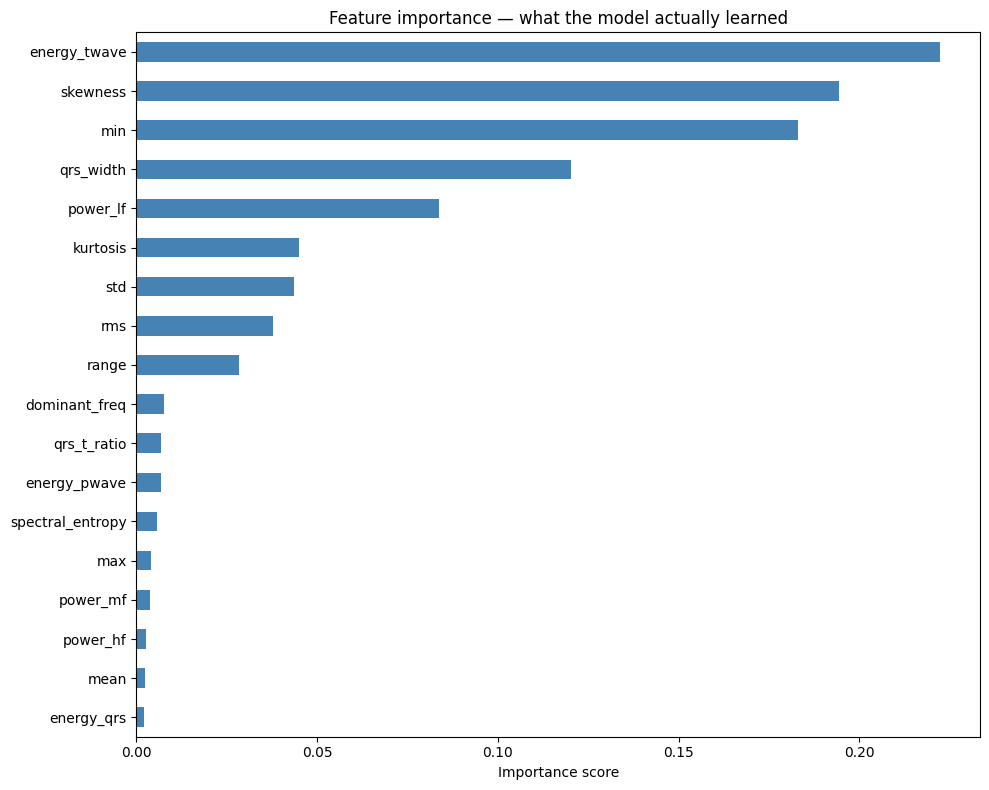

In [26]:
importances = pd.Series(clf3.feature_importances_,
                         index=X_feat_train.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature importance — what the model actually learned')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()